# Обнаружение мошенничества в банковских транзакциях

Модель классификации для выявления мошеннических транзакций с использованием CatBoost.
Данные агрегированы на уровне клиентов для надежного предсказания мошенничества.

## Часть 1: Настройка окружения

Инициализация зависимостей, логирования и параметров визуализации.

In [1]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)

# Setup
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
logger.info("Environment initialized successfully")

2026-04-08 13:28:42,107 - INFO - Environment initialized successfully


## Часть 2: Загрузка и исследование данных

Загрузка тренировочного и тестового наборов, анализ структуры и распределения мошенничества.

In [2]:
df_train = pd.read_csv("train.csv", index_col=False)
df_val = pd.read_csv("val.csv", index_col=False)
df_test = pd.read_csv("test.csv", index_col=False)

logger.info(f"Training set: {df_train.shape[0]:,} rows x {df_train.shape[1]} columns")
logger.info(f"Validation set: {df_val.shape[0]:,} rows x {df_val.shape[1]} columns")
logger.info(f"Test set: {df_test.shape[0]:,} rows x {df_test.shape[1]} columns")

logger.info(f"Fraud rate (train): {df_train['FraudResult'].mean():.2%}")
logger.info(f"Fraud rate (val): {df_val['FraudResult'].mean():.2%}")
logger.info(f"Fraud rate (test): {df_test['FraudResult'].mean():.2%}")

print("\nData Summary:")
print(f"  Training samples:   {df_train.shape[0]:>8,}")
print(f"  Validation samples: {df_val.shape[0]:>8,}")
print(f"  Test samples:       {df_test.shape[0]:>8,}")
print(f"  Features:           {df_train.shape[1]:>8}")

2026-04-08 13:28:42,211 - INFO - Training set: 54,459 rows x 10 columns
2026-04-08 13:28:42,211 - INFO - Validation set: 21,537 rows x 10 columns
2026-04-08 13:28:42,212 - INFO - Test set: 19,666 rows x 10 columns
2026-04-08 13:28:42,214 - INFO - Fraud rate (train): 0.17%
2026-04-08 13:28:42,214 - INFO - Fraud rate (val): 0.21%
2026-04-08 13:28:42,215 - INFO - Fraud rate (test): 0.29%



Data Summary:
  Training samples:     54,459
  Validation samples:   21,537
  Test samples:         19,666
  Features:                 10


### Анализ распределения энтитетов

In [3]:
# Data already split in CSV files (train.csv, val.csv, test.csv)
logger.info("Data split: using pre-split train.csv, val.csv and test.csv")

2026-04-08 13:28:42,219 - INFO - Data split: using pre-split train.csv, val.csv and test.csv


## Часть 3: Обработка признаков

Острание числовых идентификаторов, Офрормление временных признаков и кодирование категориальных полей.

### Функция обработки данных

In [4]:
def prepare_fraud_data(df):
    """
    Feature engineering and data preparation pipeline.
    """
    df = df.copy()

    id_columns = [
        "TransactionId", "CustomerId", "ProviderId", "ProductId", "ChannelId"
    ]

    for col in id_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.extract(r"(\d+)$", expand=False).astype("Int64")

    if "TransactionStartTime" in df.columns:
        df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"], utc=True)
        df["tx_year"] = df["TransactionStartTime"].dt.year
        df["tx_month"] = df["TransactionStartTime"].dt.month
        df["tx_day"] = df["TransactionStartTime"].dt.day
        df["tx_hour"] = df["TransactionStartTime"].dt.hour
        df["tx_minute"] = df["TransactionStartTime"].dt.minute
        df["tx_dayofweek"] = df["TransactionStartTime"].dt.dayofweek
        df["tx_is_weekend"] = (df["TransactionStartTime"].dt.dayofweek >= 5).astype(int)
        df = df.drop(columns=["TransactionStartTime"])

    return df.reset_index(drop=True)

### Apply Preprocessing Pipeline

In [5]:
logger.info("Starting data preprocessing...")
train_prep = prepare_fraud_data(df_train)
val_prep = prepare_fraud_data(df_val)
test_prep = prepare_fraud_data(df_test)

logger.info(f"Preprocessed training: {train_prep.shape}")
logger.info(f"Preprocessed validation: {val_prep.shape}")
logger.info(f"Preprocessed test: {test_prep.shape}")
logger.info(f"Features after preprocessing: {train_prep.shape[1]}")

2026-04-08 13:28:42,247 - INFO - Starting data preprocessing...
2026-04-08 13:28:42,473 - INFO - Preprocessed training: (54459, 16)
2026-04-08 13:28:42,474 - INFO - Preprocessed validation: (21537, 16)
2026-04-08 13:28:42,474 - INFO - Preprocessed test: (19666, 16)
2026-04-08 13:28:42,474 - INFO - Features after preprocessing: 16


### Feature Selection

In [6]:
if "ProductCategory" in train_prep.columns:
    train_prep["ProductCategory"] = train_prep["ProductCategory"].fillna("__MISSING__").astype(str)
    val_prep["ProductCategory"] = val_prep["ProductCategory"].fillna("__MISSING__").astype(str)
    test_prep["ProductCategory"] = test_prep["ProductCategory"].fillna("__MISSING__").astype(str)

    product_category_mapping = {
        category: idx
        for idx, category in enumerate(train_prep["ProductCategory"].unique())
    }

    train_prep["ProductCategory"] = (
        train_prep["ProductCategory"]
        .map(product_category_mapping)
        .fillna(-1)
        .astype(int)
    )

    val_prep["ProductCategory"] = (
        val_prep["ProductCategory"]
        .map(product_category_mapping)
        .fillna(-1)
        .astype(int)
    )

    test_prep["ProductCategory"] = (
        test_prep["ProductCategory"]
        .map(product_category_mapping)
        .fillna(-1)
        .astype(int)
    )

TARGET_COL = "FraudResult"
CLIENT_ID_COL = "CustomerId"

EXCLUDE_COLS = {
    TARGET_COL,
    "TransactionId",
    "CustomerId",
}

feature_cols = [col for col in train_prep.columns if col not in EXCLUDE_COLS]
logger.info(f"Selected {len(feature_cols)} features for modeling")
print(f"\nFeatures: {', '.join(sorted(feature_cols))}")

X_train = train_prep[feature_cols].copy()
y_train = train_prep[TARGET_COL].copy()

X_val = val_prep[feature_cols].copy()
y_val = val_prep[TARGET_COL].copy()

X_test = test_prep[feature_cols].copy()
y_test = test_prep[TARGET_COL].copy()

logger.info(f"Training set:   {len(X_train):,} samples, {y_train.mean():.2%} fraud")
logger.info(f"Validation set: {len(X_val):,} samples, {y_val.mean():.2%} fraud")
logger.info(f"Test set:       {len(X_test):,} samples, {y_test.mean():.2%} fraud")

print(f"\nMatrix dimensions:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")

2026-04-08 13:28:42,487 - INFO - Selected 13 features for modeling
2026-04-08 13:28:42,490 - INFO - Training set:   54,459 samples, 0.17% fraud
2026-04-08 13:28:42,490 - INFO - Validation set: 21,537 samples, 0.21% fraud
2026-04-08 13:28:42,491 - INFO - Test set:       19,666 samples, 0.29% fraud



Features: Amount, ChannelId, PricingStrategy, ProductCategory, ProductId, ProviderId, tx_day, tx_dayofweek, tx_hour, tx_is_weekend, tx_minute, tx_month, tx_year

Matrix dimensions:
  X_train: (54459, 13)
  y_train: (54459,)
  X_val:   (21537, 13)
  y_val:   (21537,)
  X_test:  (19666, 13)
  y_test:  (19666,)


## Часть 4: Обучение модели

Обучение классификатора CatBoost с ранней остановкой и оптимизацией AUC.

In [7]:
logger.info("Training CatBoost classifier...")

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    eval_metric='AUC',
    use_best_model=True
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    plot=False
)

logger.info("Model training completed")

2026-04-08 13:28:42,495 - INFO - Training CatBoost classifier...


0:	test: 0.9127417	best: 0.9127417 (0)	total: 59.4ms	remaining: 59.3s
100:	test: 0.9995021	best: 0.9995021 (63)	total: 499ms	remaining: 4.44s


2026-04-08 13:28:43,665 - INFO - Model training completed


200:	test: 0.9995988	best: 0.9996040 (189)	total: 944ms	remaining: 3.75s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.999603987
bestIteration = 189

Shrink model to first 190 iterations.


### Важность признаков


          ВАЖНОСТЬ ПРИЗНАКОВ (Feature Importance)           
        feature  importance
         tx_day   21.758682
      tx_minute   13.522743
   tx_dayofweek   12.299115
        tx_hour   10.725928
      ProductId    8.402154
         Amount    8.059641
     ProviderId    7.887716
       tx_month    7.836565
        tx_year    4.039277
PricingStrategy    1.850663
ProductCategory    1.679681
      ChannelId    1.386323
  tx_is_weekend    0.551512


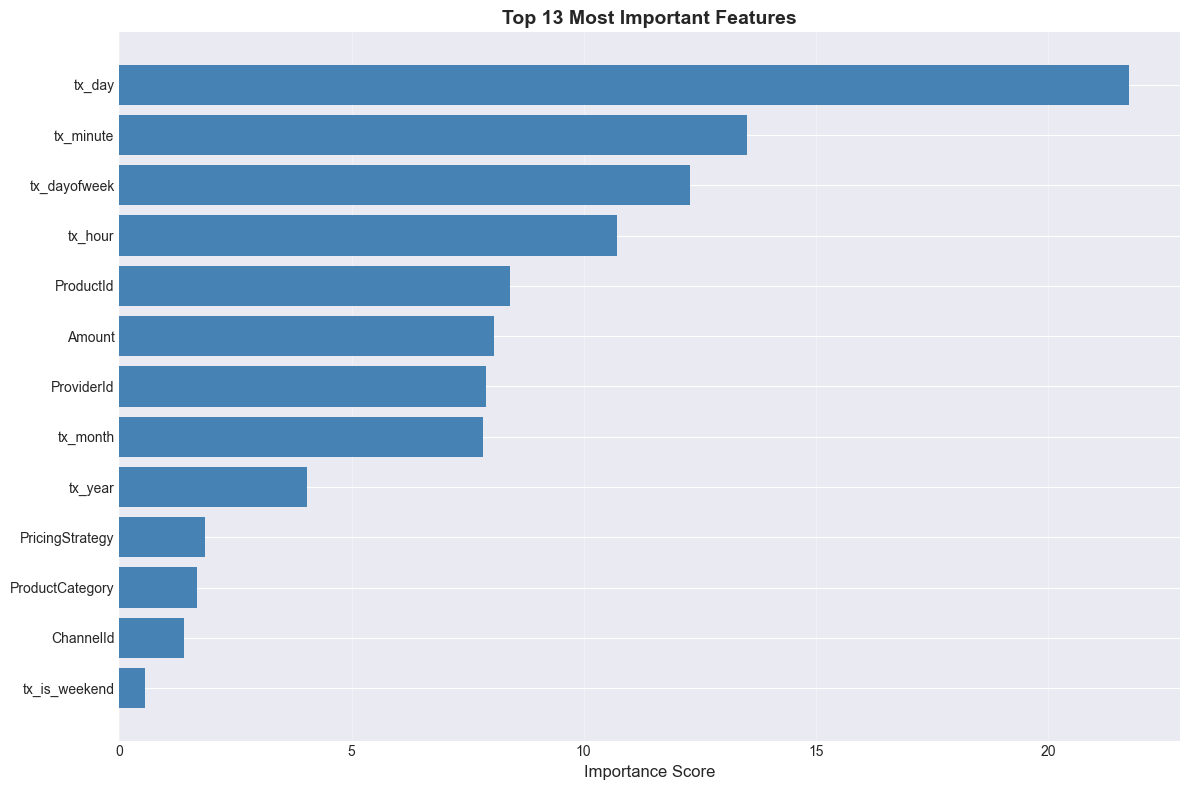

2026-04-08 13:28:43,778 - INFO - Выведено важности признаков: 13 признаков


In [8]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\n" + "=" * 60)
print("ВАЖНОСТЬ ПРИЗНАКОВ (Feature Importance)".center(60))
print("=" * 60)
print(feature_importance.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)

ax.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

logger.info(f"Выведено важности признаков: {len(feature_importance)} признаков")

## Часть 5: Инференс модели

Генерация предсказаний для тестового набора на уровне транзакций и клиентов.

In [9]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Diagnostic info
logger.info(f"Predictions generated for {len(y_pred_proba):,} test samples")
logger.info(f"Score statistics - Min: {y_pred_proba.min():.6f}, Max: {y_pred_proba.max():.6f}, Mean: {y_pred_proba.mean():.6f}")
logger.info(f"Scores >= 0.5: {(y_pred_proba >= 0.5).sum()}")

y_pred = (y_pred_proba >= 0.5).astype(int)

2026-04-08 13:28:43,785 - INFO - Predictions generated for 19,666 test samples
2026-04-08 13:28:43,785 - INFO - Score statistics - Min: 0.000001, Max: 0.959974, Mean: 0.002275
2026-04-08 13:28:43,786 - INFO - Scores >= 0.5: 43


### Агрегация на уровень клиентов

In [10]:
# Aggregate transaction-level predictions to client level
client_data = pd.DataFrame({
    CLIENT_ID_COL: test_prep[CLIENT_ID_COL].values,
    'y_true': y_test.values,
    'y_score': y_pred_proba
})

# Group by client, taking maximum score and fraud label
client_eval = client_data.groupby(CLIENT_ID_COL, as_index=False).agg({
    'y_true': 'max',
    'y_score': 'max'
})

client_eval.columns = [CLIENT_ID_COL, 'y_true_client', 'y_score_client']
client_eval['y_pred_client'] = (client_eval['y_score_client'] >= 0.5).astype(int)

logger.info(f"Aggregated to {len(client_eval):,} unique clients")
logger.info(f"Fraud cases (true): {(client_eval['y_true_client'] == 1).sum()}")
logger.info(f"Predicted fraud: {(client_eval['y_pred_client'] == 1).sum()}")
logger.info(f"Client-level score stats - Min: {client_eval['y_score_client'].min():.6f}, Max: {client_eval['y_score_client'].max():.6f}, Mean: {client_eval['y_score_client'].mean():.6f}")

2026-04-08 13:28:43,794 - INFO - Aggregated to 749 unique clients
2026-04-08 13:28:43,794 - INFO - Fraud cases (true): 9
2026-04-08 13:28:43,794 - INFO - Predicted fraud: 9
2026-04-08 13:28:43,794 - INFO - Client-level score stats - Min: 0.000003, Max: 0.959974, Mean: 0.012237


## Part 6: Model Evaluation

Calculate comprehensive metrics, visualize performance, analysis by score buckets.

2026-04-08 13:28:43,803 - INFO - Используется фиксированный порог: 0.50



         ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ CATBOOST (АГРЕГАЦИЯ НА УРОВНЕ КЛИЕНТОВ)         

СТАТИСТИКА НАБОРА ДАННЫХ:
--------------------------------------------------------------------------------
  Всего клиентов:                       749    (100.0%)
  Мошенники:                              9    (  1.2%)
  Честные:                              740    ( 98.8%)

РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
--------------------------------------------------------------------------------
  Предсказано как мошенник:              9    (  1.2%)
  Предсказано как честный:             740    ( 98.8%)
  Порог:                             0.5000

МАТРИЦА ОШИБОК:
--------------------------------------------------------------------------------
  Истинные негативы (TN):               737
  Ложные позитивы (FP):                   3
  Ложные негативы (FN):                   3
  Истинные позитивы (TP):                 6

МЕТРИКИ КАЧЕСТВА:
--------------------------------------------------------------------------------
  Ac

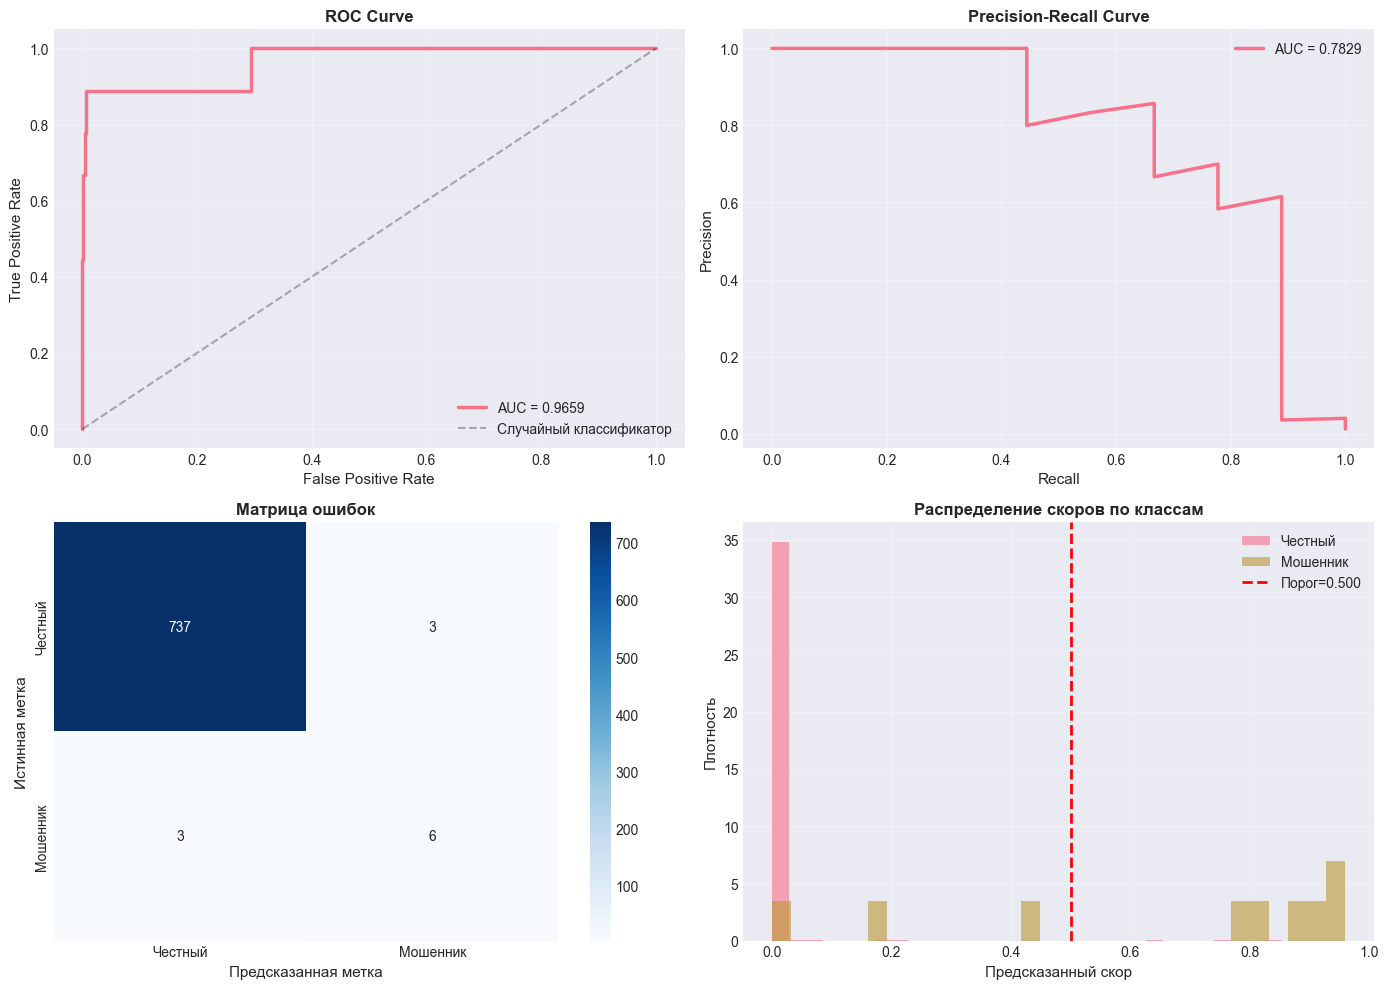

2026-04-08 13:28:44,011 - INFO - Оценка модели завершена успешно


In [11]:
y_true = client_eval['y_true_client'].values
y_score = client_eval['y_score_client'].values

# Use fixed threshold 0.5 without optimization
optimal_thresh = 0.5
y_pred = (y_score >= optimal_thresh).astype(int)

logger.info(f"Используется фиксированный порог: {optimal_thresh:.2f}")

# Calculate metrics
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics = {
    'ROC-AUC': roc_auc_score(y_true, y_score),
    'PR-AUC': average_precision_score(y_true, y_score),
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, zero_division=0),
    'Recall': recall_score(y_true, y_pred, zero_division=0),
    'F1': f1_score(y_true, y_pred, zero_division=0),
    'F0.5': fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
    'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
}

print("\n" + "=" * 80)
print("ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ CATBOOST (АГРЕГАЦИЯ НА УРОВНЕ КЛИЕНТОВ)".center(80))
print("=" * 80)

print("\nСТАТИСТИКА НАБОРА ДАННЫХ:")
print("-" * 80)
n_total = len(client_eval)
n_fraud = (y_true == 1).sum()
n_nonfraud = (y_true == 0).sum()
print(f"  Всего клиентов:                {n_total:>10,}    ({100.0:>5.1f}%)")
print(f"  Мошенники:                     {n_fraud:>10,}    ({100*n_fraud/n_total:>5.1f}%)")
print(f"  Честные:                       {n_nonfraud:>10,}    ({100*n_nonfraud/n_total:>5.1f}%)")

print("\nРАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:")
print("-" * 80)
n_pred_fraud = (y_pred == 1).sum()
n_pred_legit = (y_pred == 0).sum()
print(f"  Предсказано как мошенник:     {n_pred_fraud:>10,}    ({100*n_pred_fraud/n_total:>5.1f}%)")
print(f"  Предсказано как честный:      {n_pred_legit:>10,}    ({100*n_pred_legit/n_total:>5.1f}%)")
print(f"  Порог:                         {optimal_thresh:>10.4f}")

print("\nМАТРИЦА ОШИБОК:")
print("-" * 80)
print(f"  Истинные негативы (TN):        {tn:>10,}")
print(f"  Ложные позитивы (FP):          {fp:>10,}")
print(f"  Ложные негативы (FN):          {fn:>10,}")
print(f"  Истинные позитивы (TP):        {tp:>10,}")

print("\nМЕТРИКИ КАЧЕСТВА:")
print("-" * 80)
for metric_name, metric_value in sorted(metrics.items()):
    print(f"  {metric_name:<25} {metric_value:>10.4f}")

print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ:")
print("-" * 80)
print(classification_report(y_true, y_pred, target_names=['Честный', 'Мошенник'], 
                          digits=4, zero_division=0))

# Parity by scoring buckets
print("ПАРИТЕТ ПО БАКЕТАМ СКОРА (интервалы 0.1):")
print("-" * 80)
buckets = pd.cut(y_score, bins=10, labels=[f"{i*0.1:.1f}-{(i+1)*0.1:.1f}" for i in range(10)])
parity_df = pd.DataFrame({
    'bucket': buckets,
    'y_true': y_true,
    'y_score': y_score
})

parity_stats = parity_df.groupby('bucket', observed=True).agg({
    'y_true': ['count', 'sum', 'mean'],
    'y_score': ['min', 'max', 'mean']
}).round(4)

parity_stats.columns = ['count', 'fraud_count', 'fraud_rate', 'score_min', 'score_max', 'score_mean']
print(parity_stats.to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
axes[0, 0].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {metrics["ROC-AUC"]:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Случайный классификатор')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# PR Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
axes[0, 1].plot(recall_vals, precision_vals, linewidth=2.5, label=f'AUC = {metrics["PR-AUC"]:.4f}')
axes[0, 1].set_xlabel('Recall', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
           xticklabels=['Честный', 'Мошенник'],
           yticklabels=['Честный', 'Мошенник'])
axes[1, 0].set_ylabel('Истинная метка', fontsize=11)
axes[1, 0].set_xlabel('Предсказанная метка', fontsize=11)
axes[1, 0].set_title('Матрица ошибок', fontsize=12, fontweight='bold')

# Score Distribution
axes[1, 1].hist(y_score[y_true == 0], bins=30, alpha=0.6, label='Честный', density=True)
axes[1, 1].hist(y_score[y_true == 1], bins=30, alpha=0.6, label='Мошенник', density=True)
axes[1, 1].axvline(optimal_thresh, color='red', linestyle='--', linewidth=2, label=f'Порог={optimal_thresh:.3f}')
axes[1, 1].set_xlabel('Предсказанный скор', fontsize=11)
axes[1, 1].set_ylabel('Плотность', fontsize=11)
axes[1, 1].set_title('Распределение скоров по классам', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 80)
logger.info("Оценка модели завершена успешно")